In [1]:
from plastic_neuron import PlasticNeuron
from abstract_neuron import AbstractNeuron
from neuron_utils import NeuronUtils
from neuron_plots import NeuronPlots
import matplotlib.pyplot as plt
from neuron import h
import numpy as np
import pandas as pd

In [2]:
# idxs = np.arange(0, 30)
idxs = [0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19]

In [3]:
for idx in idxs:
    results = pd.read_csv(f"output/temporal-interference/subthreshold_conductance2/{idx}_results.csv")
    print(np.any(results.Correct), idx)

True 0
True 1
True 4
True 5
True 6
True 7
True 8
True 9
True 10
True 11
True 12
True 13
True 14
True 15
True 16
True 17
True 19


In [4]:
idx = 1
results = pd.read_csv(f"output/temporal-interference/subthreshold_conductance2/{idx}_results.csv")
conductance = results.iloc[-1].Conductance

# assert not np.any(results.Correct)
# 
# min_conductance = results[results.SpikeDuring]["Conductance"].min()
# max_conductance = results[results.SpikeDuring == False]["Conductance"].max()
# 
# # conductance = (min_conductance * 0.125 + max_conductance * 1.875) / 2
# conductance = max_conductance
# 
# print(f"Max conductance: {format(min_conductance, '.10f')}")
# print(f"Min conductance: {format(max_conductance, '.10f')}")
# 
print(f"Conductance:     {format(conductance, '.20f')}")
print(f"                 {format(results.iloc[-2].Conductance, '.20f')}")
# print(f"Actual average:  {format((min_conductance + max_conductance) / 2, '.10f')}")

Conductance:     0.00009062499999999999
                 0.00009375000000000000


In [5]:
results

,Conductance,SpikeBefore,SpikeAfter,SpikeDuring,DendriticSpikes,Correct,Step
0,0.000075,False,False,False,0.0,False,0.000025
1,0.000100,False,True,True,1.0,False,0.000013
2,0.000087,False,False,False,0.0,False,0.000006
3,0.000094,False,True,True,1.0,False,0.000003
4,0.000091,False,False,True,1.0,True,0.000002


In [8]:
test_stimulus_1 = 100
test_stimulus_2 = 2500

time_before = 50
time_after = 100

seed_idx = idx
seeds = pd.read_csv("output/temporal-interference/seeds.csv", index_col = 0)
seed = int(seeds.iloc[seed_idx].Seed)

duration = 3000
ltp_start = 1000
ltp_duration = 1000
ltp_frequency = 100

n_synapses = 10
initial_weight = 0.1

In [9]:
def generate_ltp_spike_times():
    """Generate Poisson-distributed spike times."""
    spikes = []
    t = test_stimulus_1
    spikes.append(t)

    t = ltp_start
    while t < ltp_start + ltp_duration:
        spikes.append(t)
        isi = int(1000 / ltp_frequency)
        t += isi

    t = test_stimulus_2
    spikes.append(t)

    return spikes

In [10]:
# Define the stimulus
def ltp_stimulus():
    # Generate spike times
    spike_times = generate_ltp_spike_times()

    spike_vec = h.Vector(spike_times)
    stimulus = h.VecStim()
    stimulus.play(spike_vec)

    return stimulus

In [11]:
neuron = PlasticNeuron(
    n_synapses = n_synapses,
    seed = seed,
    initial_conductance = conductance,
    initial_weight = initial_weight,
    generate_stimulus = ltp_stimulus
)

Creating cell
	1 
	1 
	0 
23 
After any change to cell geometry or nseg, be sure to invoke setpointers()
Generating synapse information
Inserting 10 synapses


In [12]:
NeuronUtils.set_stimulus(duration = 0)
neuron.set_initial_conductance(conductance)
neuron.run(duration = duration)

Neuron initialized
Elapsed time: 68.75 seconds


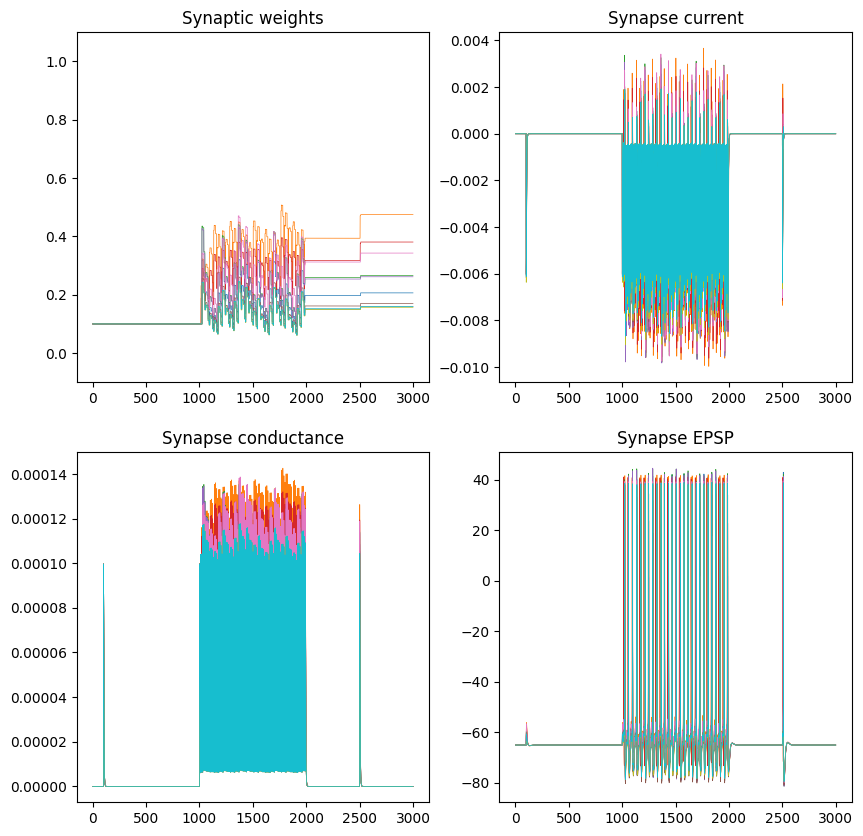

In [13]:
NeuronPlots.plot_all_synapses(neuron)

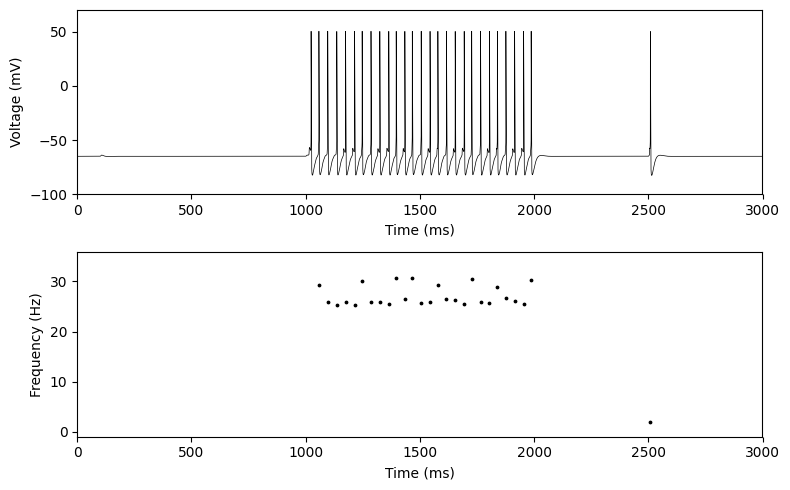

In [14]:
NeuronPlots.plot_spike_frequency(neuron)

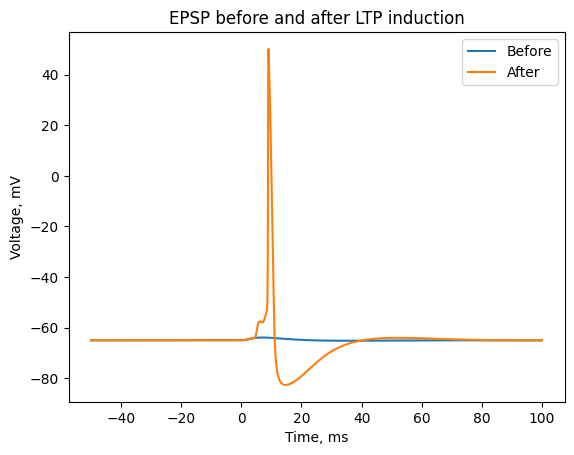

In [15]:
epsp_before = np.array(neuron.voltage[np.where(np.logical_and(neuron.time > test_stimulus_1 - time_before, neuron.time < test_stimulus_1 + time_after))[0]].tolist())
epsp_after = np.array(neuron.voltage[np.where(np.logical_and(neuron.time > test_stimulus_2 - time_before, neuron.time < test_stimulus_2 + time_after))[0]].tolist())

time = np.arange(-time_before, time_after + 0.025, 0.025)

plt.ylabel("Voltage, mV")
plt.xlabel("Time, ms")

plt.plot(
    time[:len(epsp_before)],
    epsp_before,
    label = "Before"
)

plt.plot(
    time[:len(epsp_after)],
    epsp_after,
    label = "After"
)

plt.title(f"EPSP before and after LTP induction")
plt.legend(loc = "upper right")
plt.grid(False)

plt.show()

In [16]:
NeuronUtils.set_stimulus(
    duration = ltp_duration + 200,
    delay = ltp_start - 100,
    frequency1 = 1000,
    frequency2 = 1005,
    amplitude = 134,
    phase = 10
)
neuron.set_initial_conductance(conductance)
neuron.run(duration = duration)

Neuron initialized
Elapsed time: 69.30 seconds


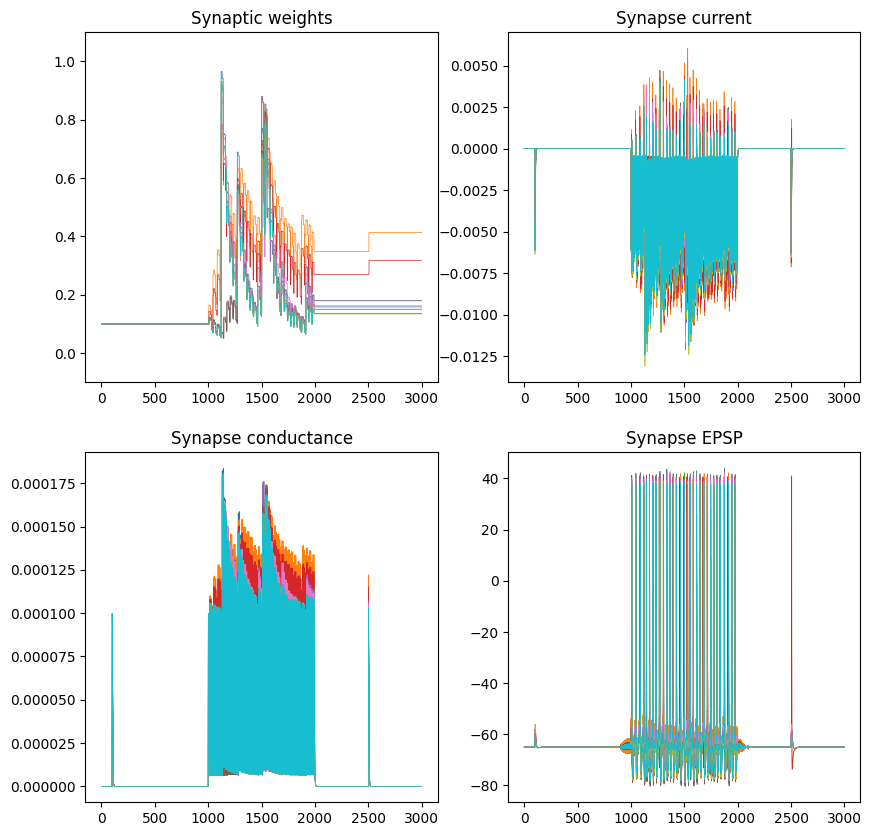

In [17]:
NeuronPlots.plot_all_synapses(neuron)

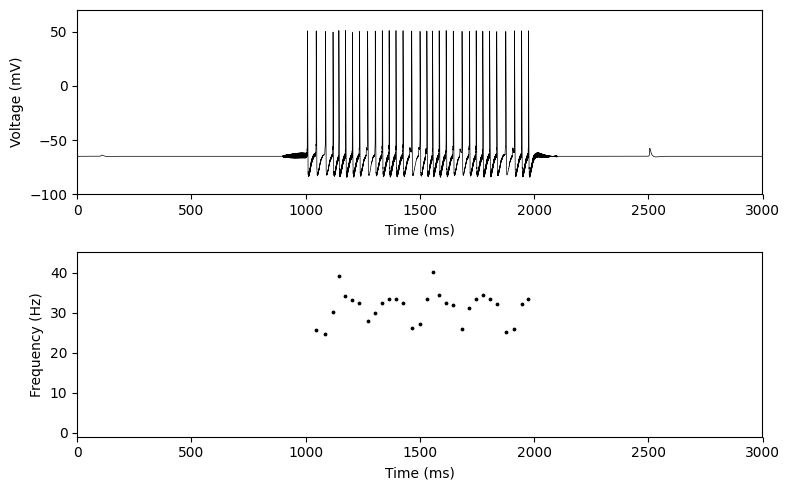

In [18]:
NeuronPlots.plot_spike_frequency(neuron)

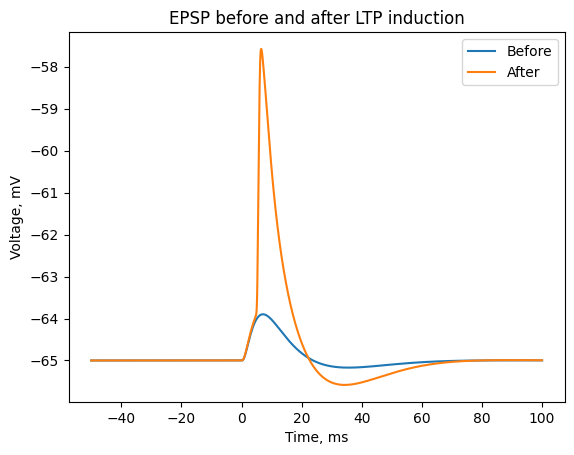

In [19]:
epsp_before = np.array(neuron.voltage[np.where(np.logical_and(neuron.time > test_stimulus_1 - time_before, neuron.time < test_stimulus_1 + time_after))[0]].tolist())
epsp_after = np.array(neuron.voltage[np.where(np.logical_and(neuron.time > test_stimulus_2 - time_before, neuron.time < test_stimulus_2 + time_after))[0]].tolist())

time = np.arange(-time_before, time_after + 0.025, 0.025)

plt.ylabel("Voltage, mV")
plt.xlabel("Time, ms")

plt.plot(
    time[:len(epsp_before)],
    epsp_before,
    label = "Before"
)

plt.plot(
    time[:len(epsp_after)],
    epsp_after,
    label = "After"
)

plt.title(f"EPSP before and after LTP induction")
plt.legend(loc = "upper right")
plt.grid(False)

plt.show()